In [1]:
!pip install plotly

   ---------------------------------------- 0.0/15.6 MB ? eta -:--:--
    --------------------------------------- 0.3/15.6 MB 5.4 MB/s eta 0:00:03
   - -------------------------------------- 0.6/15.6 MB 6.2 MB/s eta 0:00:03
   -- ------------------------------------- 0.8/15.6 MB 5.7 MB/s eta 0:00:03
   ---- ----------------------------------- 1.6/15.6 MB 8.3 MB/s eta 0:00:02
   ---- ----------------------------------- 1.9/15.6 MB 8.6 MB/s eta 0:00:02
   ------ --------------------------------- 2.6/15.6 MB 9.1 MB/s eta 0:00:02
   ------- -------------------------------- 2.8/15.6 MB 8.4 MB/s eta 0:00:02
   -------- ------------------------------- 3.3/15.6 MB 8.8 MB/s eta 0:00:02
   --------- ------------------------------ 3.9/15.6 MB 9.1 MB/s eta 0:00:02
   ----------- ---------------------------- 4.3/15.6 MB 9.2 MB/s eta 0:00:02
   ------------ --------------------------- 4.8/15.6 MB 9.4 MB/s eta 0:00:02
   ------------- -------------------------- 5.2/15.6 MB 9.2 MB/s eta 0:00:02
   ---

In [2]:
import pandas as pd
import plotly.graph_objects as go

In [8]:
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv("C:/Users/Dell/Downloads/New folder/bank-full.csv", sep=";")

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [10]:
total_contacts = len(df)

converted = df[df["y"] == "yes"].shape[0]

not_converted = df[df["y"] == "no"].shape[0]

print("Total Contacts:", total_contacts)
print("Subscribed:", converted)
print("Not Subscribed:", not_converted)

Total Contacts: 45211
Subscribed: 5289
Not Subscribed: 39922


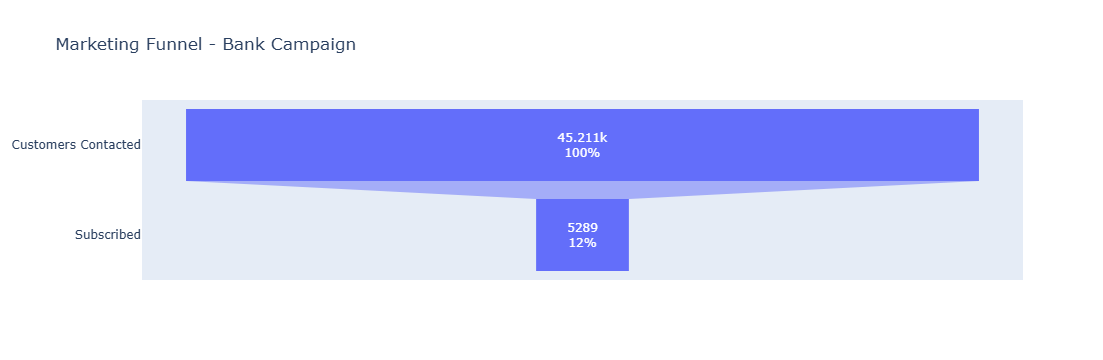

In [11]:
fig = go.Figure(go.Funnel(
    y = ["Customers Contacted", "Subscribed"],
    x = [total_contacts, converted],
    textinfo = "value+percent previous"
))

fig.update_layout(
    title = "Marketing Funnel - Bank Campaign"
)

fig.show()

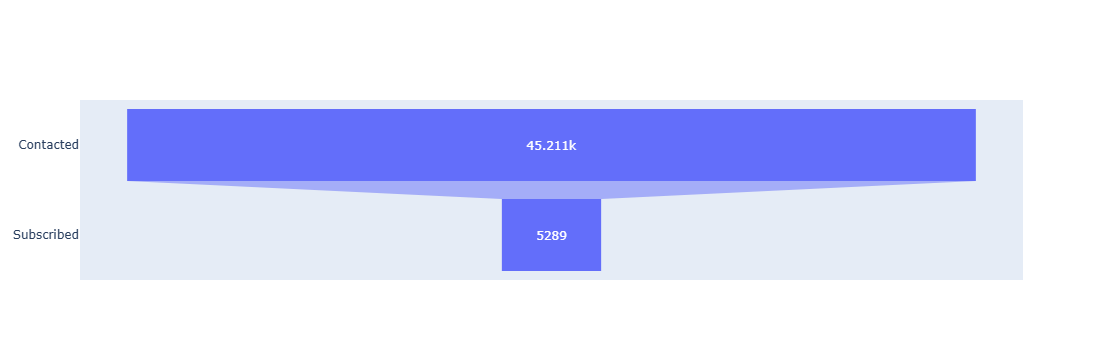

In [16]:
import plotly.graph_objects as go

fig = go.Figure(go.Funnel(
    y = ["Contacted", "Subscribed"],
    x = [total_contacts, converted]
))

fig.show()

In [12]:
channel_conversion = df.groupby(["contact","y"]).size().unstack()

channel_conversion

y,no,yes
contact,,
cellular,24916,4369
telephone,2516,390
unknown,12490,530


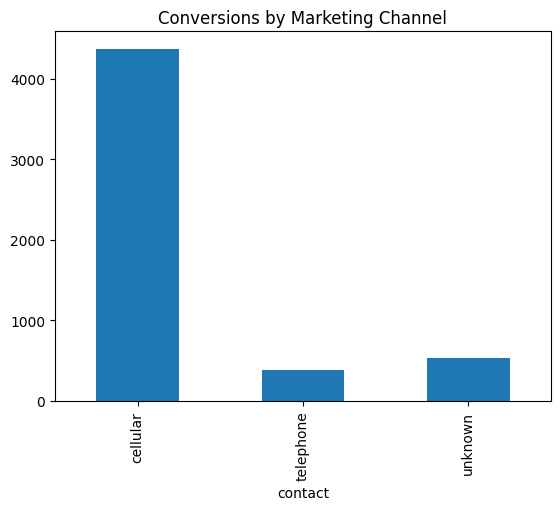

In [13]:
channel_conversion["yes"].plot(kind="bar")

plt.title("Conversions by Marketing Channel")

plt.show()

In [14]:
print("Total Customers Contacted:", total_contacts)

print("Total Conversions:", converted)

conversion_rate = converted / total_contacts

print("Conversion Rate:", round(conversion_rate*100,2), "%")

Total Customers Contacted: 45211
Total Conversions: 5289
Conversion Rate: 11.7 %


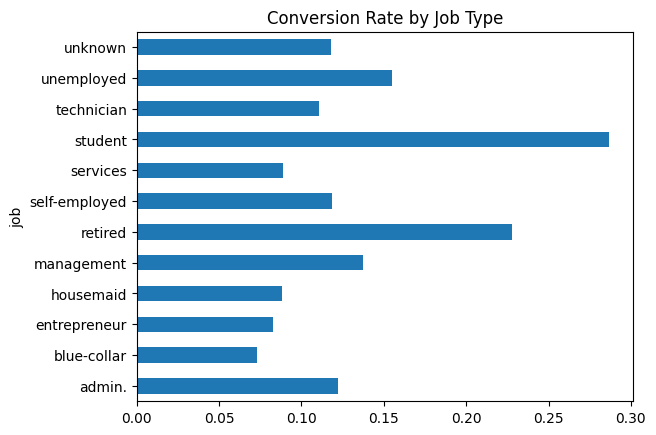

In [18]:
job_conversion = pd.crosstab(df["job"], df["y"])

job_rate = job_conversion.div(job_conversion.sum(axis=1), axis=0)

job_rate["yes"].plot(kind="barh")

plt.title("Conversion Rate by Job Type")
plt.show()

## Key Insights

• Majority of customers did not subscribe to the campaign.  
• Cellular marketing channel produces better conversions.  
• Certain job categories show higher subscription rates.  

## Recommendations

• Focus marketing efforts on high-converting segments.  
• Improve campaign targeting strategy.  
• Optimize contact channels for better engagement.